# Análisis espacial preliminar de la mortalidad por cánceres prioritarios en Colombia

**Autor:**  Miguel Ángel Pérez Vargas[✉](mailto:vargasmiguel@uninorte.edu.co)

Este notebook presenta una exploración espacial preliminar de la mortalidad por cáncer de pulmón, estómago y colorrectal en Colombia durante el periodo 2010–2024. El análisis busca caracterizar la distribución territorial de las defunciones y construir medidas de riesgo que sirvan como punto de partida para el posterior modelamiento jerárquico bayesiano.

## 1. Configuración y carga de datos

In [44]:
from pathlib import Path
import sys
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadstat
import geopandas as gpd
import mapclassify

from IPython.display import display, HTML

RUTA_PROYECTO = Path(r"C:\Users\USER\Desktop\Tesis")
RUTA_DATOS = RUTA_PROYECTO / "Data"
RUTA_DIRECTORIOS = RUTA_PROYECTO / "Directorios"
RUTA_SRC = RUTA_PROYECTO / "src"

if str(RUTA_SRC) not in sys.path:
    sys.path.append(str(RUTA_SRC))

from eda_toolkit import *

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

if "df_estomago" not in globals():
    df_estomago, meta_estomago = pyreadstat.read_sav(
        RUTA_DATOS / "ESTOMAGO2008_2024.sav"
    )
    print("Dataset de cáncer de estómago cargado correctamente.")
else:
    print("Dataset de cáncer de estómago ya disponible en memoria.")

if "df_pulmon" not in globals():
    df_pulmon, meta_pulmon = pyreadstat.read_sav(
        RUTA_DATOS / "PULMÓN2008_2024.sav"
    )
    print("Dataset de cáncer de pulmón cargado correctamente.")
else:
    print("Dataset de cáncer de pulmón ya disponible en memoria.")

if "df_colorrectal" not in globals():
    df_colorrectal = pd.read_excel(
        RUTA_DATOS / "COL_ANO_2010_2024.xlsx"
    )
    print("Dataset de cáncer colorrectal cargado correctamente.")
else:
    print("Dataset de cáncer colorrectal ya disponible en memoria.")

Dataset de cáncer de estómago ya disponible en memoria.
Dataset de cáncer de pulmón ya disponible en memoria.
Dataset de cáncer colorrectal ya disponible en memoria.


## 2. Preparación de los datos espaciales

En esta sección se integran los registros de mortalidad con la información geográfica necesaria para representar espacialmente los patrones observados a nivel departamental y municipal.

### 2.1 Carga y estructura de la información geográfica

Se carga la información geográfica correspondiente a los municipios de Colombia, la cual contiene los códigos territoriales del DANE, los nombres de municipios y departamentos, y sus respectivas geometrías. Esta información constituye la base espacial para representar posteriormente la distribución territorial de la mortalidad.

In [14]:
RUTA_GEOGRAFIA = RUTA_DATOS / "Geografia" / "shapefile"

gdf_colombia = gpd.read_file(
    RUTA_GEOGRAFIA / "MPM_FuenteCensal_2018.shp"
)

print("Dimensiones:", gdf_colombia.shape)
print("CRS:", gdf_colombia.crs)

Dimensiones: (1122, 54)
CRS: EPSG:4686


In [15]:
tabla_geografia = gdf_colombia[
    [
        "DPTO_CCDGO",
        "MPIO_CCDGO",
        "MPIO_CCNCT",
        "MPIO_CNMBR",
        "DPTO_CNMBR"
    ]
].head()

styled_geografia = tabla_geografia.style.hide(axis="index").set_table_styles([
    {
        "selector": "",
        "props": [
            ("margin-left", "auto"),
            ("margin-right", "auto"),
            ("width", "auto"),
            ("border-collapse", "collapse")
        ]
    },
    {
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("background-color", "#f2f2f2"),
            ("color", "black"),
            ("font-weight", "bold"),
            ("border", "1px solid black"),
            ("padding", "10px")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center"),
            ("border", "1px solid black"),
            ("padding", "10px")
        ]
    }
])

styled_geografia = styled_geografia.set_properties(
    subset=["MPIO_CNMBR", "DPTO_CNMBR"],
    **{"text-align": "left"}
)

display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_geografia.to_html()
        + "</div>"
    )
)

DPTO_CCDGO,MPIO_CCDGO,MPIO_CCNCT,MPIO_CNMBR,DPTO_CNMBR
18,001,18001,FLORENCIA,CAQUETÁ
18,029,18029,ALBANIA,CAQUETÁ
18,094,18094,BELÉN DE LOS ANDAQUÍES,CAQUETÁ
18,247,18247,EL DONCELLO,CAQUETÁ
18,256,18256,EL PAUJÍL,CAQUETÁ


### 2.2 Construcción del identificador territorial

Los registros de mortalidad identifican el lugar de residencia mediante códigos separados para departamento y municipio. Para vincular estos registros con la información geográfica, se construye un código DANE municipal de cinco dígitos, formado por el código del departamento y el código del municipio.

Se utiliza el municipio de residencia del fallecido como referencia territorial, permitiendo asociar las defunciones con la población y el área geográfica correspondiente.

In [16]:
def construir_codigo_dane(df):
    df = df.copy()

    dpto = pd.to_numeric(df["CODPTORE"], errors="coerce").astype("Int64")
    mpio = pd.to_numeric(df["CODMUNRE"], errors="coerce").astype("Int64")

    df["COD_DANE"] = (
        dpto.astype("string").str.zfill(2)
        + mpio.astype("string").str.zfill(3)
    )

    return df

df_estomago = construir_codigo_dane(df_estomago)
df_pulmon = construir_codigo_dane(df_pulmon)
df_colorrectal = construir_codigo_dane(df_colorrectal)

gdf_colombia["COD_DANE"] = (
    gdf_colombia["MPIO_CCNCT"]
    .astype("string")
    .str.zfill(5)
)

### 2.3 Validación de la correspondencia geográfica

Se verifica la correspondencia entre los códigos municipales presentes en los registros de mortalidad y los códigos disponibles en la información geográfica. Esta validación permite identificar registros que pueden ser asociados correctamente con un municipio antes de realizar la agregación y representación espacial.

In [18]:
resultados_validacion = []

for nombre, df in {
    "Estómago": df_estomago,
    "Pulmón": df_pulmon,
    "Colorrectal": df_colorrectal
}.items():
    coincidencia = df["COD_DANE"].isin(gdf_colombia["COD_DANE"])

    resultados_validacion.append({
        "Cáncer": nombre,
        "Registros totales": len(df),
        "Registros identificados": coincidencia.sum(),
        "Sin correspondencia": (~coincidencia).sum(),
        "Correspondencia (%)": coincidencia.mean() * 100
    })

tabla_validacion = pd.DataFrame(resultados_validacion)

styled_validacion = tabla_validacion.style.hide(axis="index").set_table_styles([
    {
        "selector": "",
        "props": [
            ("margin-left", "auto"),
            ("margin-right", "auto"),
            ("width", "auto"),
            ("border-collapse", "collapse")
        ]
    },
    {
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("background-color", "#f2f2f2"),
            ("color", "black"),
            ("font-weight", "bold"),
            ("border", "1px solid black"),
            ("padding", "10px")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center"),
            ("border", "1px solid black"),
            ("padding", "10px")
        ]
    }
])

styled_validacion = styled_validacion.format({
    "Registros totales": "{:,.0f}",
    "Registros identificados": "{:,.0f}",
    "Sin correspondencia": "{:,.0f}",
    "Correspondencia (%)": "{:.2f}%"
})

styled_validacion = styled_validacion.set_properties(
    subset=["Cáncer"],
    **{"text-align": "left"}
)

display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_validacion.to_html()
        + "</div>"
    )
)

Cáncer,Registros totales,Registros identificados,Sin correspondencia,Correspondencia (%)
Estómago,"85,128","84,976",152,99.82%
Pulmón,"74,922","74,730",192,99.74%
Colorrectal,"56,394","56,307",87,99.85%


La correspondencia entre los registros de mortalidad y la información geográfica **supera el 99 %** para los tres tipos de cáncer analizados. Esto indica una alta cobertura espacial de los datos y permite continuar con la agregación territorial de las defunciones. Los registros sin correspondencia geográfica se conservan en las bases originales, pero se excluyen de los análisis que requieren identificación municipal.

## 3. Distribución espacial de la mortalidad

En esta sección se analiza la distribución territorial de las defunciones por cáncer de pulmón, estómago y colorrectal durante el periodo 2010–2024. Los registros se agregan inicialmente a nivel municipal para identificar diferencias en la distribución espacial de la mortalidad antes de incorporar medidas de riesgo ajustadas por población.

### 3.1 Consolidación de las defunciones por municipio

Se seleccionan los registros correspondientes al periodo 2010–2024 y se agregan las defunciones según municipio de residencia, año y tipo de cáncer. Esta estructura permite disponer de una base común para comparar los patrones espaciales y temporales de los tres cánceres analizados.

In [19]:
def agregar_defunciones(df, cancer):
    base = df.copy()

    base["ANO"] = pd.to_numeric(base["ANO"], errors="coerce")

    base = base[
        base["ANO"].between(2010, 2024)
        & base["COD_DANE"].isin(gdf_colombia["COD_DANE"])
    ].copy()

    base = (
        base.groupby(["COD_DANE", "ANO"])
        .size()
        .reset_index(name="Defunciones")
    )

    base["Cáncer"] = cancer

    return base

def_estomago = agregar_defunciones(df_estomago, "Estómago")
def_pulmon = agregar_defunciones(df_pulmon, "Pulmón")
def_colorrectal = agregar_defunciones(df_colorrectal, "Colorrectal")

df_mortalidad = pd.concat(
    [def_estomago, def_pulmon, def_colorrectal],
    ignore_index=True
)

df_mortalidad["ANO"] = df_mortalidad["ANO"].astype(int)

In [22]:
tabla_resumen = tabla_resumen.rename(columns={
    "Registros_georreferenciados": "Registros georreferenciados",
    "Año_inicial": "Año inicial",
    "Año_final": "Año final"
})

styled_resumen = tabla_resumen.style.hide(axis="index").set_table_styles([
    {
        "selector": "",
        "props": [
            ("margin-left", "auto"),
            ("margin-right", "auto"),
            ("width", "auto"),
            ("border-collapse", "collapse")
        ]
    },
    {
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("background-color", "#f2f2f2"),
            ("color", "black"),
            ("font-weight", "bold"),
            ("border", "1px solid black"),
            ("padding", "10px")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center"),
            ("border", "1px solid black"),
            ("padding", "10px")
        ]
    }
])

styled_resumen = styled_resumen.format({
    "Registros_georreferenciados": "{:,.0f}",
    "Municipios": "{:,.0f}",
    "Año_inicial": "{:.0f}",
    "Año_final": "{:.0f}"
})

styled_resumen = styled_resumen.set_properties(
    subset=["Cáncer"],
    **{"text-align": "left"}
)

display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_resumen.to_html()
        + "</div>"
    )
)

Cáncer,Registros georreferenciados,Municipios,Año inicial,Año final
Colorrectal,56307,"1,067",2010,2024
Estómago,76013,"1,092",2010,2024
Pulmón,67034,"1,069",2010,2024


La base espacial consolidada contiene los registros de mortalidad correspondientes al periodo 2010–2024 que pudieron asociarse con un municipio válido en la información geográfica. Estos registros constituyen la base utilizada para las visualizaciones y análisis espaciales posteriores.

### 3.2 Revisión de registros sin correspondencia geográfica

Se examinan los registros de mortalidad que no pudieron asociarse con un municipio presente en la información geográfica. Esta revisión permite identificar los códigos territoriales responsables de la falta de correspondencia y documentar su tratamiento antes de realizar las representaciones espaciales.

In [24]:
sin_correspondencia = []

for nombre, df in {
    "Estómago": df_estomago,
    "Pulmón": df_pulmon,
    "Colorrectal": df_colorrectal
}.items():
    base = df[
        pd.to_numeric(df["ANO"], errors="coerce").between(2010, 2024)
    ].copy()

    base = base[
        ~base["COD_DANE"].isin(gdf_colombia["COD_DANE"])
    ].copy()

    resumen = (
        base.groupby(
            ["CODPTORE", "CODMUNRE", "COD_DANE"],
            dropna=False
        )
        .size()
        .reset_index(name="Registros")
        .sort_values("Registros", ascending=False)
    )

    resumen.insert(0, "Cáncer", nombre)
    sin_correspondencia.append(resumen)

tabla_sin_correspondencia = pd.concat(
    sin_correspondencia,
    ignore_index=True
)

In [32]:
resultados_revision = []

for nombre, df in {
    "Estómago": df_estomago,
    "Pulmón": df_pulmon,
    "Colorrectal": df_colorrectal
}.items():
    base = df[
        pd.to_numeric(df["ANO"], errors="coerce").between(2010, 2024)
    ].copy()

    base = base[
        ~base["COD_DANE"].isin(gdf_colombia["COD_DANE"])
    ].copy()

    dpto = pd.to_numeric(base["CODPTORE"], errors="coerce")

    sin_info = dpto.isna()
    codigo_01 = dpto.eq(1)
    codigo_75 = dpto.eq(75)
    otros = ~(sin_info | codigo_01 | codigo_75)

    resultados_revision.append({
        "Cáncer": nombre,
        "Sin correspondencia": len(base),
        "Sin información": sin_info.sum(),
        "Código 01": codigo_01.sum(),
        "Código 75": codigo_75.sum(),
        "Otros códigos": otros.sum()
    })

tabla_revision = pd.DataFrame(resultados_revision)

styled_revision = tabla_revision.style.hide(axis="index").set_table_styles([
    {
        "selector": "",
        "props": [
            ("margin-left", "auto"),
            ("margin-right", "auto"),
            ("width", "auto"),
            ("border-collapse", "collapse")
        ]
    },
    {
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("background-color", "#f2f2f2"),
            ("color", "black"),
            ("font-weight", "bold"),
            ("border", "1px solid black"),
            ("padding", "10px")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center"),
            ("border", "1px solid black"),
            ("padding", "10px")
        ]
    }
])

styled_revision = styled_revision.format({
    "Sin correspondencia": "{:,.0f}",
    "Sin información": "{:,.0f}",
    "Código 01": "{:,.0f}",
    "Código 75": "{:,.0f}",
    "Otros códigos": "{:,.0f}"
})

styled_revision = styled_revision.set_properties(
    subset=["Cáncer"],
    **{"text-align": "left"}
)

display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_revision.to_html()
        + "</div>"
    )
)

Cáncer,Sin correspondencia,Sin información,Código 01,Código 75,Otros códigos
Estómago,109,50,26,28,5
Pulmón,140,45,44,44,7
Colorrectal,87,30,35,18,4


Los registros sin correspondencia geográfica se concentran principalmente en casos sin información territorial, registros con código departamental `01` y registros con código `75`.

El directorio de variables identifica el código `01` como "Sin información". Por otra parte, los registros con código `75` se presentan únicamente entre 2010 y 2018 y no tienen correspondencia con la cartografía utilizada. Debido a que su equivalencia territorial no puede establecerse con la información disponible, estos registros no se reasignan a ningún municipio y se mantienen en las bases originales, pero se excluyen del análisis espacial municipal.

### 3.3 Distribución municipal de las defunciones acumuladas

Se representa la distribución espacial de las defunciones acumuladas por cáncer de estómago, pulmón y colorrectal durante el periodo 2010–2024. Estos mapas muestran la frecuencia observada de mortalidad en cada municipio y constituyen una primera aproximación descriptiva a los patrones espaciales presentes en los datos.

Los conteos observados no representan directamente el riesgo de mortalidad, debido a que no consideran las diferencias en el tamaño de la población entre municipios.

In [33]:
defunciones_acumuladas = (
    df_mortalidad
    .groupby(["COD_DANE", "Cáncer"], as_index=False)
    .agg(Defunciones=("Defunciones", "sum"))
)

mapas_mortalidad = {}

for cancer in ["Estómago", "Pulmón", "Colorrectal"]:
    datos_cancer = defunciones_acumuladas[
        defunciones_acumuladas["Cáncer"] == cancer
    ][["COD_DANE", "Defunciones"]]

    mapa = gdf_colombia[
        ["COD_DANE", "MPIO_CNMBR", "DPTO_CNMBR", "geometry"]
    ].merge(
        datos_cancer,
        on="COD_DANE",
        how="left"
    )

    mapa["Defunciones"] = mapa["Defunciones"].fillna(0)

    mapas_mortalidad[cancer] = mapa

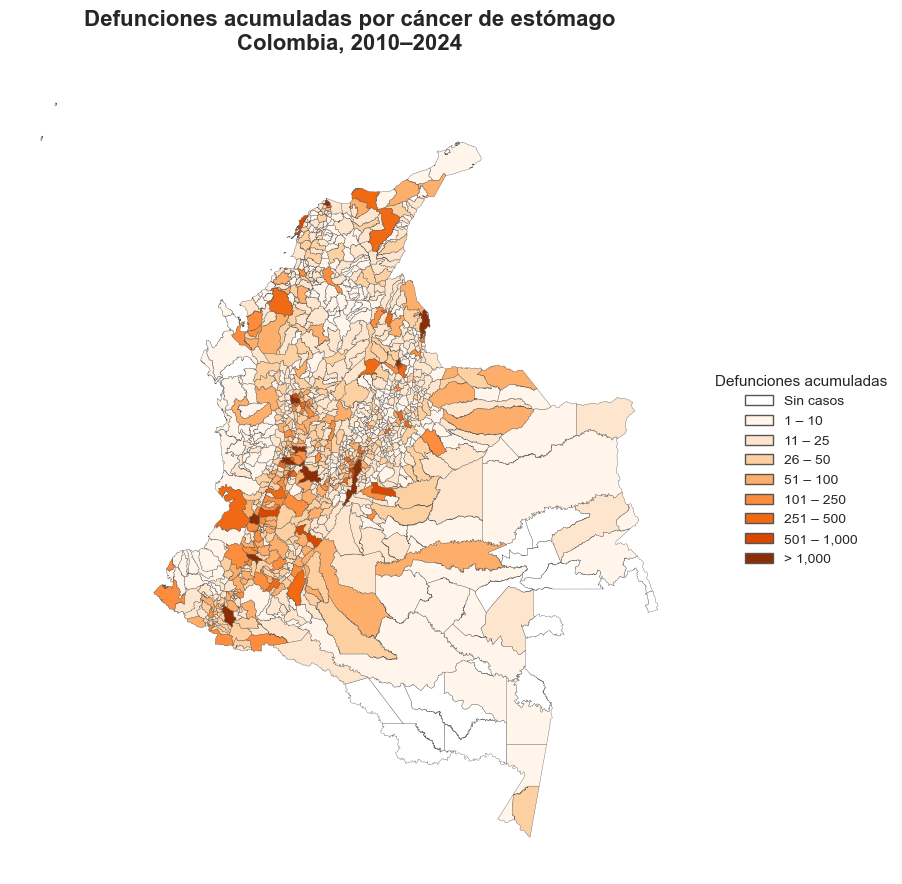

In [46]:
cancer = "Estómago"
datos = mapas_mortalidad[cancer].copy()

datos["Categoría"] = pd.cut(
    datos["Defunciones"],
    bins=[-0.1, 0, 10, 25, 50, 100, 250, 500, 1000, np.inf],
    labels=[
        "Sin casos",
        "1 – 10",
        "11 – 25",
        "26 – 50",
        "51 – 100",
        "101 – 250",
        "251 – 500",
        "501 – 1,000",
        "> 1,000"
    ]
)

orden = [
    "Sin casos",
    "1 – 10",
    "11 – 25",
    "26 – 50",
    "51 – 100",
    "101 – 250",
    "251 – 500",
    "501 – 1,000",
    "> 1,000"
]

colores = {
    "Sin casos": "#ffffff",
    "1 – 10": "#fff5eb",
    "11 – 25": "#fee6ce",
    "26 – 50": "#fdd0a2",
    "51 – 100": "#fdae6b",
    "101 – 250": "#fd8d3c",
    "251 – 500": "#f16913",
    "501 – 1,000": "#d94801",
    "> 1,000": "#8c2d04"
}

fig, ax = plt.subplots(figsize=(11, 9))

for categoria in orden:
    datos[datos["Categoría"] == categoria].plot(
        ax=ax,
        color=colores[categoria],
        edgecolor="#555555",
        linewidth=0.25
    )

leyenda = [
    Patch(
        facecolor=colores[categoria],
        edgecolor="#555555",
        label=categoria
    )
    for categoria in orden
]

ax.legend(
    handles=leyenda,
    title="Defunciones acumuladas",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

ax.set_title(
    "Defunciones acumuladas por cáncer de estómago\nColombia, 2010–2024",
    fontsize=16,
    fontweight="bold",
    pad=12
)

ax.axis("off")

plt.tight_layout()
plt.show()

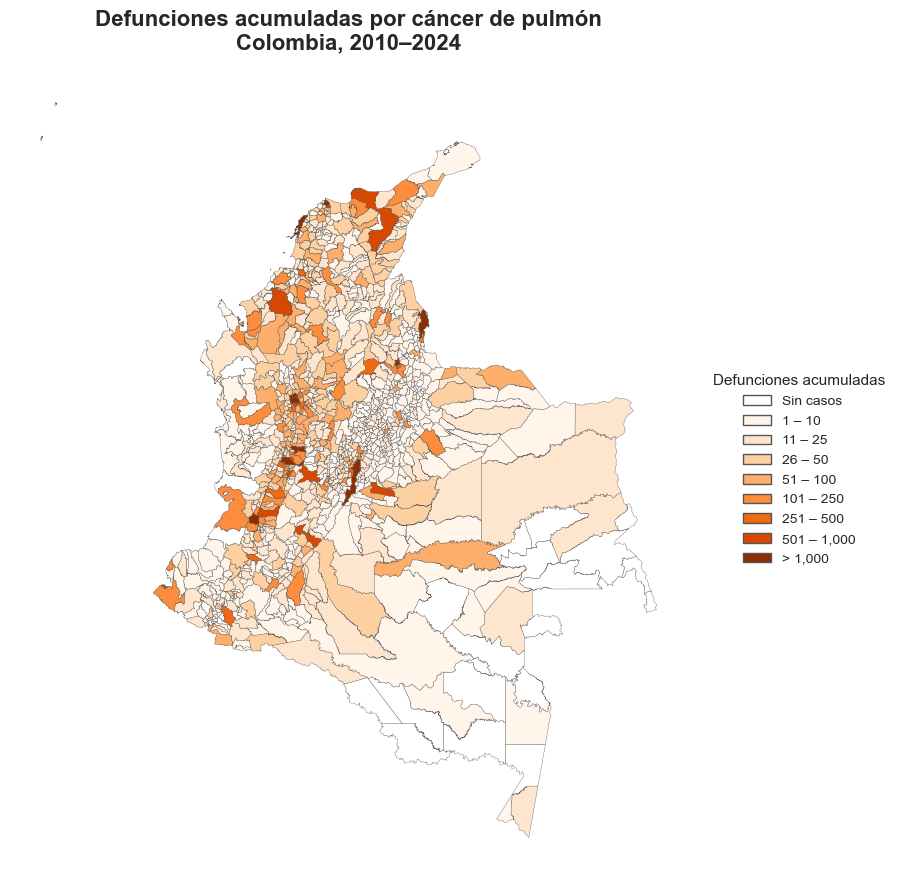

In [47]:
cancer = "Pulmón"
datos = mapas_mortalidad[cancer].copy()

datos["Categoría"] = pd.cut(
    datos["Defunciones"],
    bins=[-0.1, 0, 10, 25, 50, 100, 250, 500, 1000, np.inf],
    labels=[
        "Sin casos",
        "1 – 10",
        "11 – 25",
        "26 – 50",
        "51 – 100",
        "101 – 250",
        "251 – 500",
        "501 – 1,000",
        "> 1,000"
    ]
)

orden = [
    "Sin casos",
    "1 – 10",
    "11 – 25",
    "26 – 50",
    "51 – 100",
    "101 – 250",
    "251 – 500",
    "501 – 1,000",
    "> 1,000"
]

colores = {
    "Sin casos": "#ffffff",
    "1 – 10": "#fff5eb",
    "11 – 25": "#fee6ce",
    "26 – 50": "#fdd0a2",
    "51 – 100": "#fdae6b",
    "101 – 250": "#fd8d3c",
    "251 – 500": "#f16913",
    "501 – 1,000": "#d94801",
    "> 1,000": "#8c2d04"
}

fig, ax = plt.subplots(figsize=(11, 9))

for categoria in orden:
    datos[datos["Categoría"] == categoria].plot(
        ax=ax,
        color=colores[categoria],
        edgecolor="#555555",
        linewidth=0.25
    )

leyenda = [
    Patch(
        facecolor=colores[categoria],
        edgecolor="#555555",
        label=categoria
    )
    for categoria in orden
]

ax.legend(
    handles=leyenda,
    title="Defunciones acumuladas",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

ax.set_title(
    "Defunciones acumuladas por cáncer de pulmón\nColombia, 2010–2024",
    fontsize=16,
    fontweight="bold",
    pad=12
)

ax.axis("off")

plt.tight_layout()
plt.show()

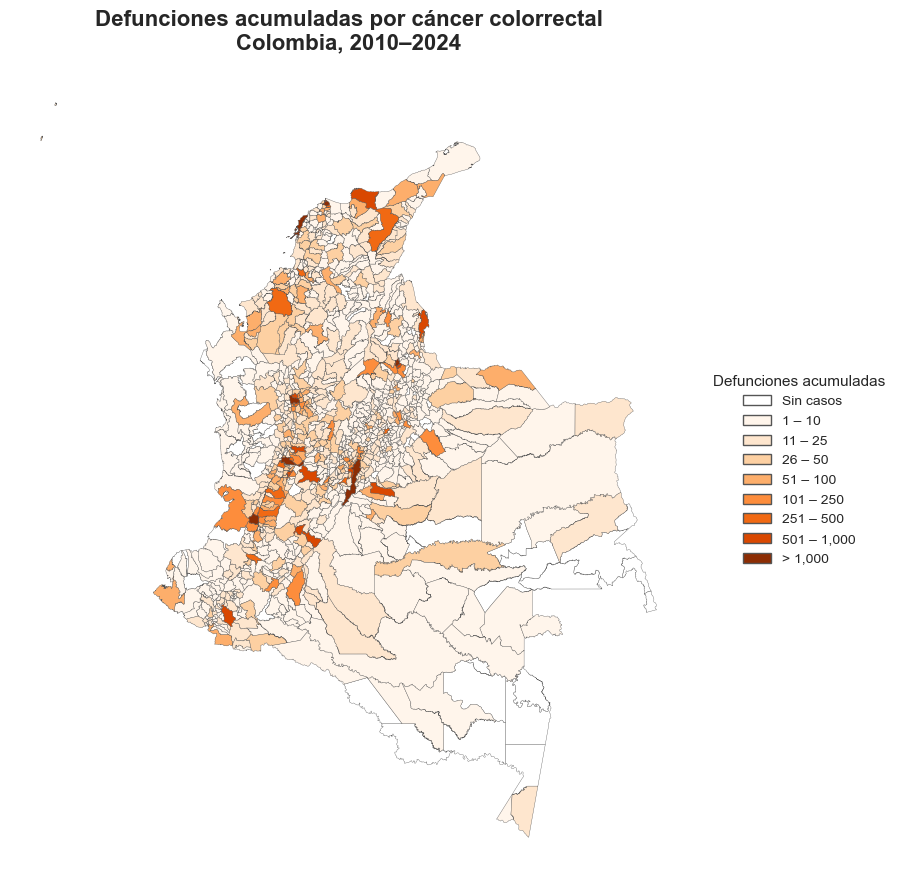

In [48]:
cancer = "Colorrectal"
datos = mapas_mortalidad[cancer].copy()

datos["Categoría"] = pd.cut(
    datos["Defunciones"],
    bins=[-0.1, 0, 10, 25, 50, 100, 250, 500, 1000, np.inf],
    labels=[
        "Sin casos",
        "1 – 10",
        "11 – 25",
        "26 – 50",
        "51 – 100",
        "101 – 250",
        "251 – 500",
        "501 – 1,000",
        "> 1,000"
    ]
)

orden = [
    "Sin casos",
    "1 – 10",
    "11 – 25",
    "26 – 50",
    "51 – 100",
    "101 – 250",
    "251 – 500",
    "501 – 1,000",
    "> 1,000"
]

colores = {
    "Sin casos": "#ffffff",
    "1 – 10": "#fff5eb",
    "11 – 25": "#fee6ce",
    "26 – 50": "#fdd0a2",
    "51 – 100": "#fdae6b",
    "101 – 250": "#fd8d3c",
    "251 – 500": "#f16913",
    "501 – 1,000": "#d94801",
    "> 1,000": "#8c2d04"
}

fig, ax = plt.subplots(figsize=(11, 9))

for categoria in orden:
    datos[datos["Categoría"] == categoria].plot(
        ax=ax,
        color=colores[categoria],
        edgecolor="#555555",
        linewidth=0.25
    )

leyenda = [
    Patch(
        facecolor=colores[categoria],
        edgecolor="#555555",
        label=categoria
    )
    for categoria in orden
]

ax.legend(
    handles=leyenda,
    title="Defunciones acumuladas",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

ax.set_title(
    "Defunciones acumuladas por cáncer colorrectal\nColombia, 2010–2024",
    fontsize=16,
    fontweight="bold",
    pad=12
)

ax.axis("off")

plt.tight_layout()
plt.show()

Los tres cánceres presentan una distribución espacial similar en los conteos acumulados de defunciones, con una mayor concentración en municipios que contienen grandes centros urbanos. Sin embargo, estos resultados corresponden a frecuencias absolutas y están influenciados por las diferencias en el tamaño de la población municipal.

Por esta razón, los conteos observados permiten describir la distribución territorial de las defunciones, pero no deben interpretarse directamente como una medida de riesgo. Para realizar comparaciones entre municipios es necesario incorporar la población y estimar medidas de mortalidad relativa.

### 3.4 Razón Estandarizada de Mortalidad (SMR)

Los conteos absolutos de defunciones están condicionados por el tamaño de la población de cada municipio, por lo que no permiten comparar directamente la mortalidad entre territorios. Para realizar una comparación relativa se utiliza la Razón Estandarizada de Mortalidad (SMR), definida como:

$$
SMR_i = \frac{O_i}{E_i}
$$

donde $O_i$ corresponde al número de defunciones observadas y $E_i$ al número de defunciones esperadas en el municipio $i$.

Un valor de $SMR_i = 1$ indica que las defunciones observadas coinciden con las esperadas; valores superiores a 1 indican un exceso de mortalidad respecto a lo esperado y valores inferiores a 1 indican una mortalidad observada menor a la esperada.

#### 3.4.1 Preparación de los estratos de edad

Para estimar las defunciones esperadas se armonizan los grupos de edad de los registros de mortalidad con los estratos disponibles en las estimaciones de población. Los códigos con correspondencia documentada se agrupan en los mismos intervalos utilizados por la base poblacional.

Los registros cuya categoría de edad no puede asociarse a un estrato poblacional se conservan en la base original, pero no se utilizan en la estandarización por edad.

In [64]:
mapa_edad = {
    10: "menor_40",
    11: "menor_40",
    12: "menor_40",
    13: "menor_40",
    14: "menor_40",
    15: "40_44",
    16: "45_49",
    17: "50_54",
    18: "55_59",
    19: "60_64",
    20: "65_69",
    21: "70_74",
    22: "75_79",
    23: "80_84",
    24: "mayor_84"
}

estomago_2020_2024 = df_estomago[
    pd.to_numeric(df_estomago["ANO"], errors="coerce").between(2020, 2024)
].copy()

estomago_2020_2024["GRU_ED1"] = pd.to_numeric(
    estomago_2020_2024["GRU_ED1"],
    errors="coerce"
)

estomago_2020_2024["Grupo_edad"] = (
    estomago_2020_2024["GRU_ED1"].map(mapa_edad)
)

resumen_edad = pd.DataFrame({
    "Clasificación": [
        "Defunciones totales",
        "Edad compatible con población",
        "Edad sin correspondencia"
    ],
    "Registros": [
        len(estomago_2020_2024),
        estomago_2020_2024["Grupo_edad"].notna().sum(),
        estomago_2020_2024["Grupo_edad"].isna().sum()
    ]
})

resumen_edad["Porcentaje"] = [
    "100.0%",
    f"{estomago_2020_2024['Grupo_edad'].notna().mean() * 100:.1f}%",
    f"{estomago_2020_2024['Grupo_edad'].isna().mean() * 100:.1f}%"
]

resumen_edad["Registros"] = resumen_edad["Registros"].map(
    lambda x: f"{x:,}"
)

styled_resumen = resumen_edad.style.hide(axis="index").set_table_styles([
    {
        "selector": "",
        "props": [
            ("margin-left", "auto"),
            ("margin-right", "auto"),
            ("width", "auto"),
            ("border-collapse", "collapse")
        ]
    },
    {
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("background-color", "#f2f2f2"),
            ("color", "black"),
            ("font-weight", "bold"),
            ("border", "1px solid black"),
            ("padding", "10px")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center"),
            ("border", "1px solid black"),
            ("padding", "10px")
        ]
    }
])

styled_resumen = styled_resumen.set_properties(
    subset=["Clasificación"],
    **{"text-align": "left"}
)

display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_resumen.to_html()
        + "</div>"
    )
)

Clasificación,Registros,Porcentaje
Defunciones totales,"26,418",100.0%
Edad compatible con población,"23,516",89.0%
Edad sin correspondencia,"2,902",11.0%


De las 26.418 defunciones por cáncer de estómago registradas entre 2020 y 2024, 23.516 (89,0 %) presentan una categoría de edad compatible con los estratos de la población utilizada para la estandarización. Los 2.902 registros restantes (11,0 %) corresponden a categorías que no pueden asociarse directamente con los grupos poblacionales disponibles y, por tanto, no se incorporan al cálculo estandarizado por edad.

Estos registros se conservan en la base original y continúan formando parte de los análisis que no requieren estratificación por edad.

#### 3.4.2 Defunciones observadas por estrato

Para la estandarización indirecta, las defunciones se organizan según año, sexo y grupo de edad. Se consideran únicamente los registros con categorías de edad y sexo compatibles con los estratos disponibles en las estimaciones poblacionales.

In [74]:
esperados_estrato = poblacion_municipal_larga.merge(
    tasas_nacionales[
        ["ANO", "Sexo", "Grupo_edad", "Tasa"]
    ],
    on=["ANO", "Sexo", "Grupo_edad"],
    how="left",
    validate="many_to_one"
)

esperados_estrato["Esperadas"] = (
    esperados_estrato["Poblacion"]
    * esperados_estrato["Tasa"]
)

esperados_municipales = (
    esperados_estrato
    .groupby(
        ["dpto_ccdgo", "DPNOM", "mpio_cdpmp", "DPMP"],
        as_index=False
    )
    .agg(
        Esperadas=("Esperadas", "sum")
    )
)

print("Municipios:", len(esperados_municipales))
print(
    "Estratos sin tasa:",
    esperados_estrato["Tasa"].isna().sum()
)
print(
    "Defunciones esperadas totales:",
    f"{esperados_municipales['Esperadas'].sum():,.2f}"
)

Municipios: 1123
Estratos sin tasa: 0
Defunciones esperadas totales: 23,515.00


#### 3.4.3 Tasas nacionales específicas de mortalidad

Las defunciones esperadas se estiman a partir de las tasas de mortalidad observadas en la población de referencia. Para cada año, sexo y grupo de edad se calcula una tasa nacional específica, relacionando las defunciones por cáncer de estómago con la población correspondiente al mismo estrato.

$$
r_{ast} = \frac{D_{ast}}{P_{ast}}
$$

donde $D_{ast}$ representa las defunciones observadas a nivel nacional para el grupo de edad $a$, sexo $s$ y año $t$, mientras que $P_{ast}$ corresponde a la población nacional del mismo estrato.

#### 3.4.4 Defunciones esperadas por municipio

Las tasas nacionales específicas por año, sexo y grupo de edad se aplican a la población de cada municipio en los mismos estratos. De esta forma, se estima el número de defunciones que se esperaría observar si cada municipio presentara las tasas de mortalidad de la población nacional de referencia.

$$
E_i = \sum_{a,s,t} P_{iast} \, r_{ast}
$$

donde $P_{iast}$ corresponde a la población del municipio $i$ para el grupo de edad $a$, sexo $s$ y año $t$, mientras que $r_{ast}$ representa la tasa nacional específica correspondiente al mismo estrato.

#### 3.4.5 Cálculo del SMR municipal

Una vez estimadas las defunciones esperadas, la Razón Estandarizada de Mortalidad se obtiene comparando las defunciones observadas con las esperadas para cada municipio:

$$
SMR_i = \frac{O_i}{E_i}
$$

Un valor de $SMR_i = 1$ indica que la mortalidad observada coincide con la esperada según la estructura de edad y sexo del municipio. Valores superiores a 1 representan una mortalidad mayor a la esperada, mientras que valores inferiores a 1 representan una mortalidad menor a la esperada.

In [75]:
observadas_municipales = estomago_estratos.copy()

observadas_municipales["CODPTORE"] = pd.to_numeric(
    observadas_municipales["CODPTORE"],
    errors="coerce"
)

observadas_municipales["CODMUNRE"] = pd.to_numeric(
    observadas_municipales["CODMUNRE"],
    errors="coerce"
)

observadas_municipales = observadas_municipales[
    observadas_municipales["CODPTORE"].notna()
    & observadas_municipales["CODMUNRE"].notna()
].copy()

observadas_municipales["COD_DANE"] = (
    observadas_municipales["CODPTORE"].astype(int).astype(str).str.zfill(2)
    + observadas_municipales["CODMUNRE"].astype(int).astype(str).str.zfill(3)
)

observadas_municipales = (
    observadas_municipales
    .groupby("COD_DANE", as_index=False)
    .size()
    .rename(columns={"size": "Observadas"})
)

esperados_municipales["COD_DANE"] = (
    pd.to_numeric(
        esperados_municipales["mpio_cdpmp"],
        errors="coerce"
    )
    .astype("Int64")
    .astype(str)
    .str.zfill(5)
)

smr_estomago = esperados_municipales.merge(
    observadas_municipales,
    on="COD_DANE",
    how="left"
)

smr_estomago["Observadas"] = smr_estomago["Observadas"].fillna(0)

smr_estomago["SMR"] = (
    smr_estomago["Observadas"]
    / smr_estomago["Esperadas"]
)

print("Municipios con población:", len(smr_estomago))
print("Municipios con defunciones observadas:", (smr_estomago["Observadas"] > 0).sum())
print("Defunciones observadas incorporadas:", f"{smr_estomago['Observadas'].sum():,.0f}")
print("SMR mínimo:", f"{smr_estomago['SMR'].min():.3f}")
print("SMR mediano:", f"{smr_estomago['SMR'].median():.3f}")
print("SMR máximo:", f"{smr_estomago['SMR'].max():.3f}")

Municipios con población: 1123
Municipios con defunciones observadas: 1022
Defunciones observadas incorporadas: 23,476
SMR mínimo: 0.000
SMR mediano: 0.772
SMR máximo: 4.379


De las 23.515 defunciones con información de edad y sexo compatible con la población de referencia, 23.476 pudieron asociarse con los municipios incluidos en las estimaciones poblacionales. La diferencia corresponde a 39 registros (0,17 %) sin correspondencia municipal válida para esta etapa del análisis.

El SMR municipal presenta una mediana de 0,772 y valores entre 0 y 4,379. La variabilidad observada debe interpretarse con cautela, especialmente en municipios con poblaciones pequeñas o un número reducido de defunciones, donde el SMR crudo puede presentar mayor inestabilidad.

#### 3.4.6 Distribución espacial del SMR

La distribución espacial del SMR permite identificar municipios donde la mortalidad observada por cáncer de estómago es inferior, similar o superior a la esperada después de considerar la estructura de edad y sexo de la población.

In [79]:
RUTA_SHAPEFILE = (
    RUTA_PROYECTO
    / "Data"
    / "Geografia"
    / "shapefile"
    / "MPM_FuenteCensal_2018.shp"
)

gdf_municipios = gpd.read_file(RUTA_SHAPEFILE)

gdf_municipios["MPIO_CCNCT"] = (
    gdf_municipios["MPIO_CCNCT"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(5)
)

print("Municipios cargados:", len(gdf_municipios))
print("CRS:", gdf_municipios.crs)

Municipios cargados: 1122
CRS: EPSG:4686


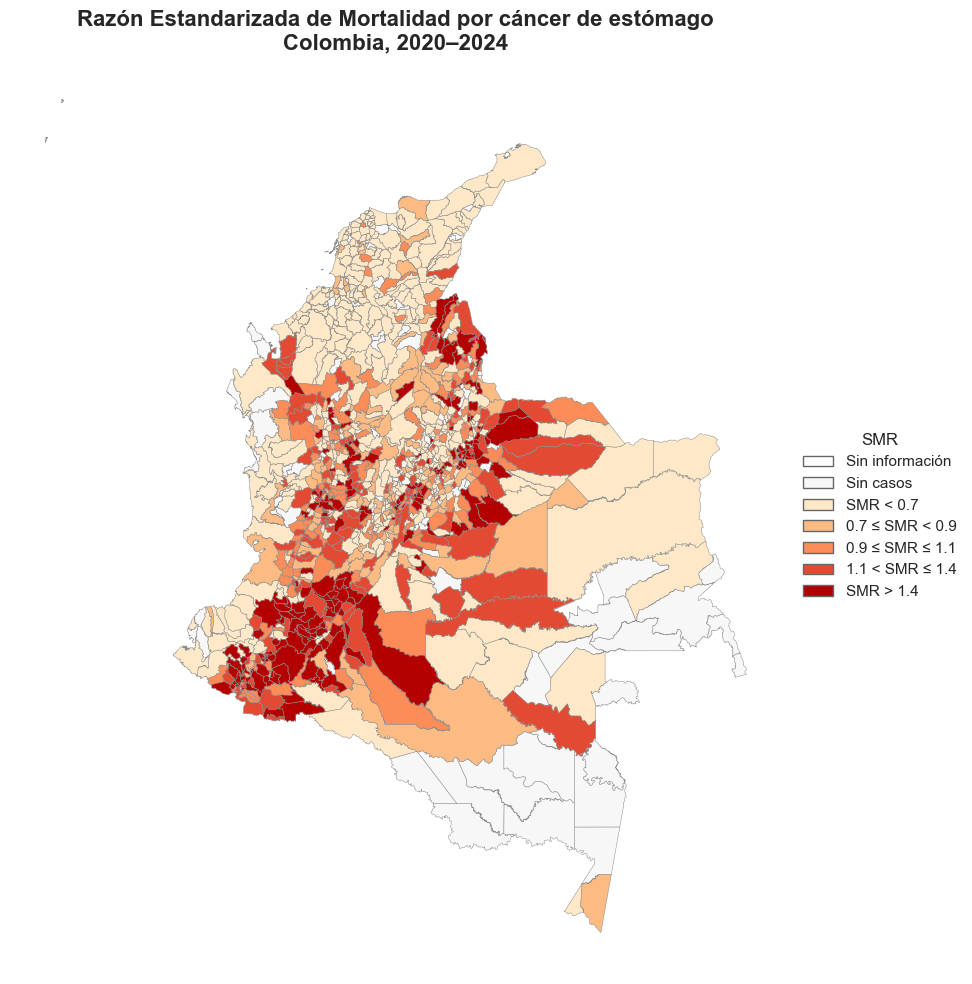

In [81]:
bins_smr = [-np.inf, 0, 0.7, 0.9, 1.1, 1.4, np.inf]

labels_smr = [
    "Sin casos",
    "SMR < 0.7",
    "0.7 ≤ SMR < 0.9",
    "0.9 ≤ SMR ≤ 1.1",
    "1.1 < SMR ≤ 1.4",
    "SMR > 1.4"
]

smr_estomago["Categoria_SMR"] = pd.cut(
    smr_estomago["SMR"],
    bins=bins_smr,
    labels=labels_smr,
    include_lowest=True
)

mapa_smr_estomago = gdf_municipios.merge(
    smr_estomago[["COD_DANE", "SMR", "Categoria_SMR"]],
    left_on="MPIO_CCNCT",
    right_on="COD_DANE",
    how="left"
)

mapa_smr_estomago["Categoria_SMR"] = (
    mapa_smr_estomago["Categoria_SMR"]
    .cat.add_categories(["Sin información"])
    .fillna("Sin información")
)

colores_smr = {
    "Sin información": "#ffffff",
    "Sin casos": "#f7f7f7",
    "SMR < 0.7": "#fee8c8",
    "0.7 ≤ SMR < 0.9": "#fdbb84",
    "0.9 ≤ SMR ≤ 1.1": "#fc8d59",
    "1.1 < SMR ≤ 1.4": "#e34a33",
    "SMR > 1.4": "#b30000"
}

fig, ax = plt.subplots(figsize=(10, 10))

for categoria, color in colores_smr.items():
    subset = mapa_smr_estomago[
        mapa_smr_estomago["Categoria_SMR"].astype(str) == categoria
    ]

    if not subset.empty:
        subset.plot(
            ax=ax,
            color=color,
            edgecolor="#8c8c8c",
            linewidth=0.35
        )

orden_leyenda = [
    "Sin información",
    "Sin casos",
    "SMR < 0.7",
    "0.7 ≤ SMR < 0.9",
    "0.9 ≤ SMR ≤ 1.1",
    "1.1 < SMR ≤ 1.4",
    "SMR > 1.4"
]

leyenda = [
    Patch(
        facecolor=colores_smr[categoria],
        edgecolor="#666666",
        label=categoria
    )
    for categoria in orden_leyenda
]

ax.legend(
    handles=leyenda,
    title="SMR",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False
)

ax.set_title(
    "Razón Estandarizada de Mortalidad por cáncer de estómago\nColombia, 2020–2024",
    fontsize=16,
    fontweight="bold"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

El mapa muestra diferencias claras en el SMR entre municipios. Aunque gran parte del territorio presenta valores inferiores a 1, también se identifican municipios donde las defunciones observadas superan las esperadas, principalmente en zonas del centro y suroccidente del país.

Estos valores corresponden al SMR sin suavizar, por lo que los resultados de municipios con pocas defunciones deben interpretarse con cautela.

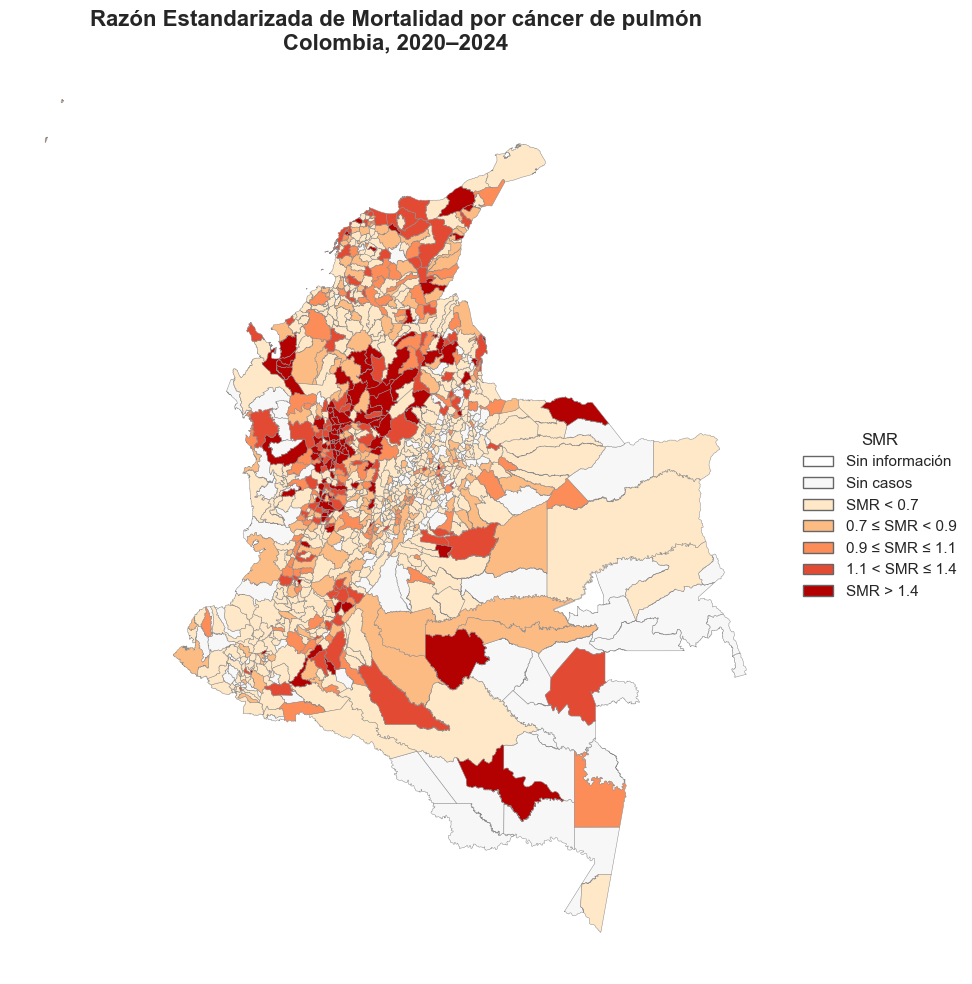

In [84]:
smr_pulmon["Categoria_SMR"] = pd.cut(
    smr_pulmon["SMR"],
    bins=bins_smr,
    labels=labels_smr,
    include_lowest=True
)

mapa_smr_pulmon = gdf_municipios.merge(
    smr_pulmon[["COD_DANE", "SMR", "Categoria_SMR"]],
    left_on="MPIO_CCNCT",
    right_on="COD_DANE",
    how="left"
)

mapa_smr_pulmon["Categoria_SMR"] = (
    mapa_smr_pulmon["Categoria_SMR"]
    .cat.add_categories(["Sin información"])
    .fillna("Sin información")
)

fig, ax = plt.subplots(figsize=(10, 10))

for categoria, color in colores_smr.items():
    subset = mapa_smr_pulmon[
        mapa_smr_pulmon["Categoria_SMR"].astype(str) == categoria
    ]

    if not subset.empty:
        subset.plot(
            ax=ax,
            color=color,
            edgecolor="#8c8c8c",
            linewidth=0.35
        )

leyenda = [
    Patch(
        facecolor=colores_smr[categoria],
        edgecolor="#666666",
        label=categoria
    )
    for categoria in orden_leyenda
]

ax.legend(
    handles=leyenda,
    title="SMR",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False
)

ax.set_title(
    "Razón Estandarizada de Mortalidad por cáncer de pulmón\nColombia, 2020–2024",
    fontsize=16,
    fontweight="bold"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

El cáncer de pulmón presenta un patrón espacial distinto al observado para el cáncer de estómago. Los municipios con SMR superior a 1 se concentran principalmente en zonas del centro y norte del país, aunque también aparecen valores elevados de forma aislada en otras regiones.

Al igual que en el cáncer de estómago, los valores corresponden al SMR sin suavizar.

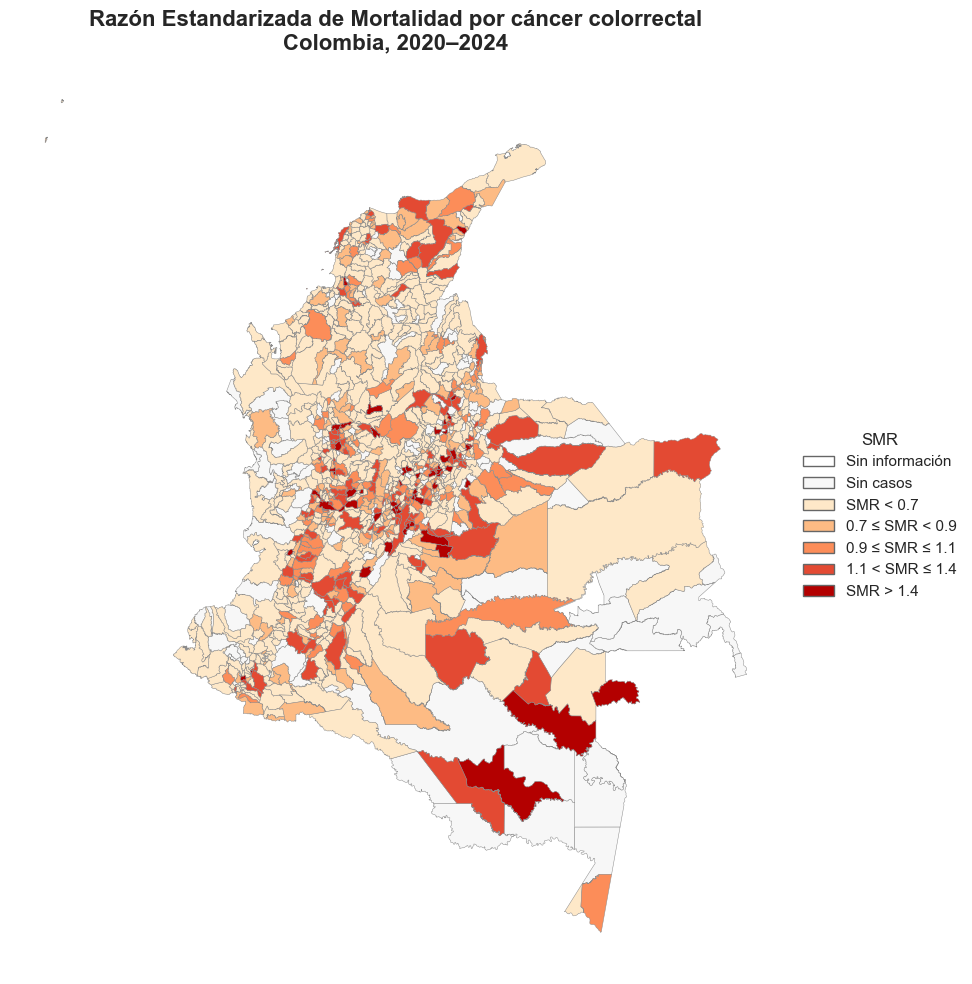

In [86]:
smr_colorrectal["Categoria_SMR"] = pd.cut(
    smr_colorrectal["SMR"],
    bins=bins_smr,
    labels=labels_smr,
    include_lowest=True
)

mapa_smr_colorrectal = gdf_municipios.merge(
    smr_colorrectal[["COD_DANE", "SMR", "Categoria_SMR"]],
    left_on="MPIO_CCNCT",
    right_on="COD_DANE",
    how="left"
)

mapa_smr_colorrectal["Categoria_SMR"] = (
    mapa_smr_colorrectal["Categoria_SMR"]
    .cat.add_categories(["Sin información"])
    .fillna("Sin información")
)

fig, ax = plt.subplots(figsize=(10, 10))

for categoria, color in colores_smr.items():
    subset = mapa_smr_colorrectal[
        mapa_smr_colorrectal["Categoria_SMR"].astype(str) == categoria
    ]

    if not subset.empty:
        subset.plot(
            ax=ax,
            color=color,
            edgecolor="#8c8c8c",
            linewidth=0.35
        )

leyenda = [
    Patch(
        facecolor=colores_smr[categoria],
        edgecolor="#666666",
        label=categoria
    )
    for categoria in orden_leyenda
]

ax.legend(
    handles=leyenda,
    title="SMR",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False
)

ax.set_title(
    "Razón Estandarizada de Mortalidad por cáncer colorrectal\nColombia, 2020–2024",
    fontsize=16,
    fontweight="bold"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

En el cáncer colorrectal predominan los municipios con SMR inferior a 1, mientras que los valores superiores a lo esperado aparecen de forma más dispersa. También se observan algunos municipios con SMR elevado hacia el sur del país.

Nuevamnte, las estimaciones no están suavizadas.

### 3.5 Comparación espacial del SMR entre cánceres

Una vez estimado el SMR municipal para los tres cánceres, se comparan sus patrones territoriales con el fin de identificar municipios que presentan simultáneamente valores elevados de mortalidad observada respecto a la esperada.

Esta comparación permite explorar si los excesos de mortalidad tienden a concentrarse en los mismos municipios o si cada cáncer presenta un patrón espacial diferente.

In [99]:
resumen_superposicion = pd.DataFrame({
    "Número de cánceres con exceso": [
        "Ninguno",
        "Uno",
        "Dos",
        "Tres"
    ],
    "SMR > 1": [
        (comparacion_smr["Cancer_sobre_1"] == 0).sum(),
        (comparacion_smr["Cancer_sobre_1"] == 1).sum(),
        (comparacion_smr["Cancer_sobre_1"] == 2).sum(),
        (comparacion_smr["Cancer_sobre_1"] == 3).sum()
    ],
    "SMR > 1.4": [
        (comparacion_smr["Cancer_sobre_1_4"] == 0).sum(),
        (comparacion_smr["Cancer_sobre_1_4"] == 1).sum(),
        (comparacion_smr["Cancer_sobre_1_4"] == 2).sum(),
        (comparacion_smr["Cancer_sobre_1_4"] == 3).sum()
    ]
})

styled_superposicion = (
    resumen_superposicion.style
    .hide(axis="index")
    .set_table_styles([
        {
            "selector": "",
            "props": [
                ("margin-left", "auto"),
                ("margin-right", "auto"),
                ("width", "auto"),
                ("border-collapse", "collapse")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("background-color", "#f2f2f2"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("border", "1px solid black"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("padding", "10px")
            ]
        }
    ])
)

display(
    HTML(
        "<div style='text-align:center; width:100%;'>"
        + styled_superposicion.to_html()
        + "</div>"
    )
)

Número de cánceres con exceso,SMR > 1,SMR > 1.4
Ninguno,477,807
Uno,442,284
Dos,168,29
Tres,36,3


La comparación muestra que la coincidencia espacial disminuye a medida que se considera un exceso de mortalidad más elevado. Con un SMR superior a 1, 168 municipios presentan exceso de mortalidad en dos de los cánceres y 36 lo presentan en los tres.

Al considerar valores de SMR superiores a 1.4, estas cifras se reducen a 29 y 3 municipios, respectivamente. Esto muestra que existen municipios donde coinciden los excesos de mortalidad, aunque la mayor parte de los valores elevados no se presenta simultáneamente en los tres cánceres.

#### 3.5.1 Municipios con SMR superior a 1.4 en los tres cánceres

Se identifican los municipios que presentan un SMR superior a 1.4 para cáncer de estómago, pulmón y colorrectal. Esto permite reconocer los territorios en los que los tres cánceres presentan más defunciones observadas de las esperadas y, además, superan el umbral utilizado para identificar los valores más elevados de SMR.

In [104]:
municipios_coincidentes = comparacion_smr.loc[
    comparacion_smr["Cancer_sobre_1_4"] == 3,
    [
        "COD_DANE",
        "SMR_Estomago",
        "SMR_Pulmon",
        "SMR_Colorrectal"
    ]
].copy()

municipios_coincidentes = municipios_coincidentes.merge(
    gdf_municipios[
        ["MPIO_CCNCT", "MPIO_CNMBR", "DPTO_CNMBR"]
    ].drop_duplicates(),
    left_on="COD_DANE",
    right_on="MPIO_CCNCT",
    how="left"
)

municipios_coincidentes = municipios_coincidentes[
    [
        "MPIO_CNMBR",
        "DPTO_CNMBR",
        "SMR_Estomago",
        "SMR_Pulmon",
        "SMR_Colorrectal"
    ]
].rename(columns={
    "MPIO_CNMBR": "Municipio",
    "DPTO_CNMBR": "Departamento",
    "SMR_Estomago": "Estómago",
    "SMR_Pulmon": "Pulmón",
    "SMR_Colorrectal": "Colorrectal"
})

styled_coincidentes = (
    municipios_coincidentes.style
    .hide(axis="index")
    .format({
        "Estómago": "{:.2f}",
        "Pulmón": "{:.2f}",
        "Colorrectal": "{:.2f}"
    })
    .set_table_styles([
        {
            "selector": "",
            "props": [
                ("margin-left", "auto"),
                ("margin-right", "auto"),
                ("width", "auto"),
                ("border-collapse", "collapse")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("background-color", "#f2f2f2"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("border", "1px solid black"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("padding", "10px")
            ]
        }
    ])
)

display(
    HTML(
        "<div style='text-align:center; width:100%;'>"
        + styled_coincidentes.to_html()
        + "</div>"
    )
)

Municipio,Departamento,Estómago,Pulmón,Colorrectal
DONMATÍAS,ANTIOQUIA,1.55,1.83,1.94
NARIÑO,NARIÑO,1.69,1.91,2.92
PEREIRA,RISARALDA,1.43,1.69,1.58


Los municipios de Donmatías (Antioquia), Nariño (Nariño) y Pereira (Risaralda) presentan valores de SMR superiores a 1.4 para los tres cánceres analizados. Nariño presenta los valores más altos para cáncer de estómago y colorrectal, mientras que en cáncer de pulmón los valores más elevados entre estos tres municipios se observan en Nariño y Donmatías.

Estos municipios constituyen los principales puntos de coincidencia identificados al comparar los patrones espaciales de los tres cánceres.
